# Rebalancing — Deep Dive
### A complete guide for quant developer interviews — from mechanics to production-grade convex optimization

---

This notebook covers:
1. What rebalancing is and why it exists — with full drift mechanics
2. The mathematics of drift over time
3. Rebalancing triggers (calendar, threshold bands, cash flow)
4. Full taxonomy of transaction costs
5. The rebalancing problem as a convex optimization (cvxpy)
6. The no-trade zone and cost-TE trade-off frontier
7. Cash flow rebalancing — optimal deployment math
8. Tax-aware rebalancing — lot selection and tax-loss harvesting
9. Smart rebalancing customizations and security transitioning
10. Systems architecture — rebalancing at scale

**Install dependencies:**
```
pip install numpy scipy matplotlib cvxpy
```

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# Try to import cvxpy — gracefully skip if not installed
try:
    import cvxpy as cp
    CVXPY_AVAILABLE = True
    print('cvxpy available — full optimization cells will run')
except ImportError:
    CVXPY_AVAILABLE = False
    print('cvxpy not installed. Run: pip install cvxpy')
    print('Optimization cells will use scipy.optimize as fallback.')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f8f8',
    'axes.grid': True, 'grid.color': 'white', 'grid.linewidth': 0.8,
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11,
})

PURPLE = '#534AB7'; TEAL   = '#1D9E75'; AMBER  = '#EF9F27'
CORAL  = '#D85A30'; BLUE   = '#185FA5'; GREEN  = '#3B6D11'
RED    = '#A32D2D'; GRAY   = '#888780'

print('Imports complete.')

cvxpy available — full optimization cells will run
Imports complete.


---
## Part 1 — What is Rebalancing and Why Does it Exist?

You invest €10,000 — €6,000 (60%) in equities, €4,000 (40%) in bonds. Equities rise 25%, bonds stay flat.

After one year: equities = €7,500, bonds = €4,000, total = €11,500.
New equity weight: $7500/11500 = 65.2\%$ — **you hold more risk than you intended.**

### How weights evolve from returns alone

Starting from weights $\mathbf{w}_0$ and cumulative return vector $\mathbf{R}$:
$$w_i(t) = \frac{w_{0,i}\,(1+R_i)}{\mathbf{w}_0^\top(\mathbf{1}+\mathbf{R})}$$

Drift is entirely determined by the **cross-sectional dispersion of asset returns**. When one asset far outperforms others, its weight balloons — silently increasing the portfolio's risk profile.

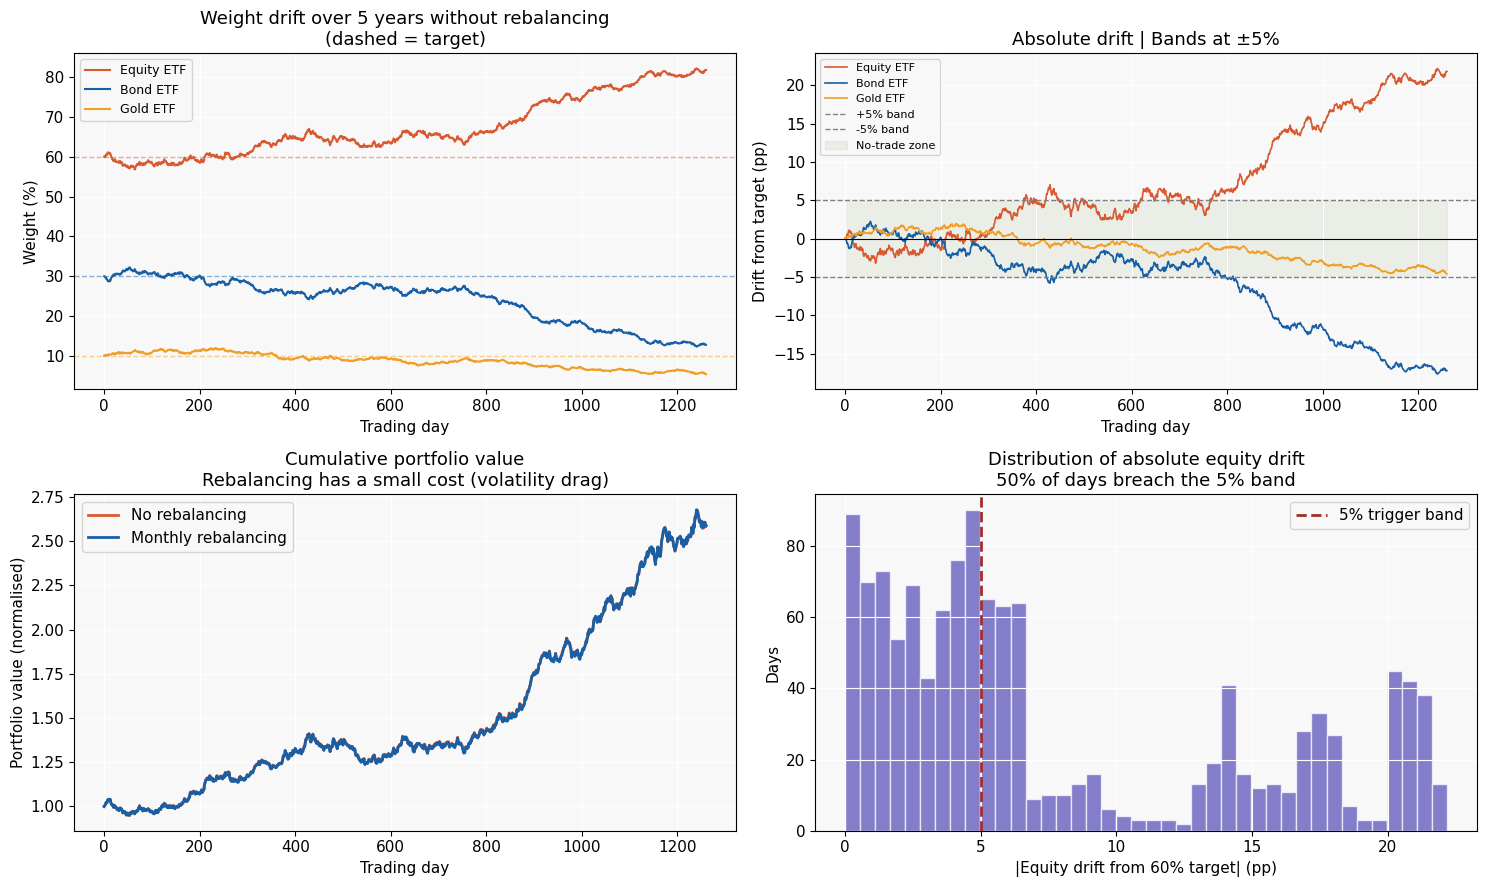

Final weights after 5 years (no rebalancing):
  Equity ETF  : 60% → 81.8%  (drift: +21.8pp)
  Bond ETF    : 30% → 12.8%  (drift: -17.2pp)
  Gold ETF    : 10% → 5.4%  (drift: -4.6pp)


In [3]:
# ── Drift simulation: how weights evolve without trading ─────────────────────
np.random.seed(42)

# 3-asset portfolio: equities, bonds, gold
asset_names   = ['Equity ETF', 'Bond ETF', 'Gold ETF']
target_weights = np.array([0.60, 0.30, 0.10])
annual_rets    = np.array([0.18, 0.02, 0.08])   # different annual return profiles
annual_vols    = np.array([0.18, 0.05, 0.15])
colors_assets  = [CORAL, BLUE, AMBER]

# Simulate 5 years of daily returns
T_years = 5
T_days  = T_years * 252
dt      = 1/252

daily_rets = np.column_stack([
    np.random.normal(r*dt, v*np.sqrt(dt), T_days)
    for r, v in zip(annual_rets, annual_vols)
])

# Track weights over time — the portfolio mechanics equation
values = target_weights.copy().astype(float)
weight_history = [target_weights.copy()]

for day_ret in daily_rets:
    values *= (1 + day_ret)
    weight_history.append(values / values.sum())

weight_history = np.array(weight_history)   # shape (T_days+1, 3)
days = np.arange(len(weight_history))

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# Top left: Weight paths over time
ax = axes[0, 0]
for i, (name, tgt, col) in enumerate(zip(asset_names, target_weights, colors_assets)):
    ax.plot(days, weight_history[:, i]*100, color=col, lw=1.5, label=name)
    ax.axhline(tgt*100, color=col, lw=1, ls='--', alpha=0.5)
ax.set_xlabel('Trading day')
ax.set_ylabel('Weight (%)')
ax.set_title('Weight drift over 5 years without rebalancing\n(dashed = target)')
ax.legend(fontsize=9)

# Top right: Absolute drift
ax = axes[0, 1]
for i, (name, tgt, col) in enumerate(zip(asset_names, target_weights, colors_assets)):
    drift = (weight_history[:, i] - tgt) * 100
    ax.plot(days, drift, color=col, lw=1.2, label=name)
ax.axhline(5,  color='gray', lw=1, ls='--', label='+5% band')
ax.axhline(-5, color='gray', lw=1, ls='--', label='-5% band')
ax.axhline(0,  color='black', lw=0.8)
ax.fill_between(days, -5, 5, alpha=0.07, color=GREEN, label='No-trade zone')
ax.set_xlabel('Trading day')
ax.set_ylabel('Drift from target (pp)')
ax.set_title('Absolute drift | Bands at ±5%')
ax.legend(fontsize=8)

# Bottom left: Cumulative growth with vs without rebalancing
ax = axes[1, 0]
port_no_rebal  = (1 + daily_rets @ target_weights).cumprod()
port_no_rebal  = np.concatenate([[1.0], port_no_rebal])

# Rebalanced portfolio (rebalance monthly)
vals_rebal = target_weights.copy().astype(float)
vals_rebal_hist = [1.0]
init_val = 1.0
for day, day_ret in enumerate(daily_rets):
    vals_rebal *= (1 + day_ret)
    if (day + 1) % 21 == 0:           # monthly rebalancing
        total = vals_rebal.sum()
        vals_rebal = target_weights * total
    vals_rebal_hist.append(vals_rebal.sum())

vals_rebal_hist = np.array(vals_rebal_hist) / vals_rebal_hist[0]

ax.plot(days, port_no_rebal,   color=CORAL,  lw=2, label='No rebalancing')
ax.plot(days, vals_rebal_hist, color=BLUE,   lw=2, label='Monthly rebalancing')
ax.set_xlabel('Trading day')
ax.set_ylabel('Portfolio value (normalised)')
ax.set_title('Cumulative portfolio value\nRebalancing has a small cost (volatility drag)')
ax.legend()

# Bottom right: Equity weight histogram
ax = axes[1, 1]
final_drift_eq = abs(weight_history[:, 0] - target_weights[0]) * 100
ax.hist(final_drift_eq, bins=40, color=PURPLE, alpha=0.7, edgecolor='white')
ax.axvline(5, color=RED, lw=2, ls='--', label='5% trigger band')
trigger_pct = (final_drift_eq > 5).mean() * 100
ax.set_xlabel('|Equity drift from 60% target| (pp)')
ax.set_ylabel('Days')
ax.set_title(f'Distribution of absolute equity drift\n{trigger_pct:.0f}% of days breach the 5% band')
ax.legend()

plt.tight_layout()
plt.show()

final_weights = weight_history[-1]
print('Final weights after 5 years (no rebalancing):')
for name, tgt, w in zip(asset_names, target_weights, final_weights):
    print(f'  {name:12s}: {tgt*100:.0f}% → {w*100:.1f}%  (drift: {(w-tgt)*100:+.1f}pp)')

---
## Part 2 — Rebalancing Triggers: Three Strategies

### Strategy 1 — Calendar (fixed schedule)
Rebalance every month/quarter. Simple, ignores actual drift. Used as a benchmark.

### Strategy 2 — Threshold bands (production standard)

**Absolute band:** fire when $|w_i(t) - w^*_i| > \varepsilon$

**Relative band:** fire when $\frac{|w_i(t) - w^*_i|}{w^*_i} > \delta$ — better for small-weight assets

**Combined (production):** fire if either absolute OR relative trigger fires.

Once triggered, you have options:
- **Full rebalance:** $\mathbf{w} \to \mathbf{w}^*$ — max cost, perfect tracking
- **Trade to inner band boundary:** cheaper, acceptable drift
- **Trade to outer band edge:** minimal trading (buy/hold style)

### Strategy 3 — Cash flow rebalancing (most cost-efficient)
Deploy client deposits / raise cash for withdrawals in a way that corrects drift — **at zero marginal cost** since you're trading anyway.

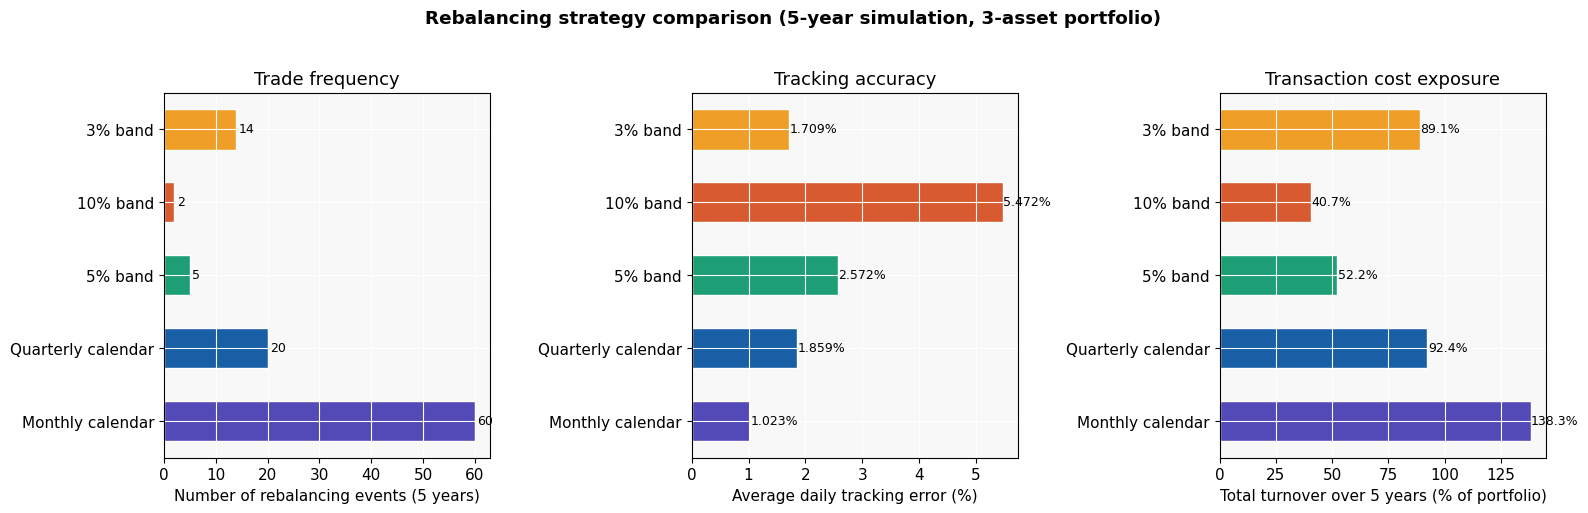

Strategy                   Trades     Avg TE     Turnover     Est cost
----------------------------------------------------------------------
Monthly calendar               60     1.023%       138.3%       0.138%
Quarterly calendar             20     1.859%        92.4%       0.092%
5% band                         5     2.572%        52.2%       0.052%
10% band                        2     5.472%        40.7%       0.041%
3% band                        14     1.709%        89.1%       0.089%


In [4]:
# ── Compare rebalancing strategies: number of trades vs tracking error ────────
def simulate_strategy(daily_rets, target, strategy='calendar', freq=21, eps=0.05):
    """
    Simulate a rebalancing strategy. Returns:
      - tracking_errors: daily TE array
      - n_trades: number of rebalancing events
      - total_turnover: sum of |weight_changes| at each rebalance
    """
    vals   = target.copy().astype(float)
    te_hist = []
    n_trades = 0
    total_turnover = 0.0

    for day, day_ret in enumerate(daily_rets):
        vals *= (1 + day_ret)
        total = vals.sum()
        w = vals / total
        drift = np.abs(w - target)
        te_hist.append(np.sqrt(drift @ drift))  # simple TE proxy

        do_rebal = False
        if strategy == 'calendar' and (day + 1) % freq == 0:
            do_rebal = True
        elif strategy == 'band' and drift.max() > eps:
            do_rebal = True
        elif strategy == 'hybrid' and (drift.max() > eps or (day+1) % freq == 0):
            do_rebal = True

        if do_rebal:
            total_turnover += drift.sum()
            n_trades += 1
            vals = target * total

    return np.array(te_hist), n_trades, total_turnover

# Run comparison
strategies = {
    'Monthly calendar': ('calendar', 21, 0.05),
    'Quarterly calendar': ('calendar', 63, 0.05),
    '5% band': ('band', 21, 0.05),
    '10% band': ('band', 21, 0.10),
    '3% band': ('band', 21, 0.03),
}

results = {}
for name, (strat, freq, eps) in strategies.items():
    te, n, turn = simulate_strategy(daily_rets, target_weights, strat, freq, eps)
    results[name] = {'te': te, 'n_trades': n, 'avg_te': te.mean()*100, 'turnover': turn*100}

# Assume 10bps transaction cost per % turnover
cost_per_turnover_pct = 0.10  # bps per 1% turnover

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

names = list(results.keys())
n_trades   = [results[n]['n_trades']  for n in names]
avg_te     = [results[n]['avg_te']    for n in names]
turnovers  = [results[n]['turnover']  for n in names]
est_costs  = [t * cost_per_turnover_pct / 100 for t in turnovers]  # in % of portfolio

bar_colors = [PURPLE, BLUE, TEAL, CORAL, AMBER]

# Trades count
axes[0].barh(names, n_trades, color=bar_colors, edgecolor='white', height=0.55)
for i, v in enumerate(n_trades):
    axes[0].text(v + 0.5, i, str(v), va='center', fontsize=9)
axes[0].set_xlabel('Number of rebalancing events (5 years)')
axes[0].set_title('Trade frequency')

# Average tracking error
axes[1].barh(names, avg_te, color=bar_colors, edgecolor='white', height=0.55)
for i, v in enumerate(avg_te):
    axes[1].text(v + 0.01, i, f'{v:.3f}%', va='center', fontsize=9)
axes[1].set_xlabel('Average daily tracking error (%)')
axes[1].set_title('Tracking accuracy')

# Total turnover cost
axes[2].barh(names, turnovers, color=bar_colors, edgecolor='white', height=0.55)
for i, v in enumerate(turnovers):
    axes[2].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)
axes[2].set_xlabel('Total turnover over 5 years (% of portfolio)')
axes[2].set_title('Transaction cost exposure')

plt.suptitle('Rebalancing strategy comparison (5-year simulation, 3-asset portfolio)',
             y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'{"Strategy":<25} {"Trades":>7} {"Avg TE":>10} {"Turnover":>12} {"Est cost":>12}')
print('-' * 70)
for name in names:
    r = results[name]
    cost = r['turnover'] * cost_per_turnover_pct / 100
    print(f'{name:<25} {r["n_trades"]:>7} {r["avg_te"]:>9.3f}% {r["turnover"]:>11.1f}% {cost:>11.3f}%')

---
## Part 3 — Transaction Cost Taxonomy

Every rebalancing trade has costs. Understanding each component is essential.

| Cost type | Formula | Typical size (liquid ETF) |
|---|---|---|
| Commission | Fixed € + proportional | ~0 at Scalable Capital |
| Bid-ask spread | $0.5 \cdot \text{spread} \cdot |\Delta w_i| \cdot V$ | 2–5 bps one-way |
| Market impact | $\eta \cdot \sigma \cdot \sqrt{|x|/ADV}$ | ~0 for robo-advisor trade sizes |
| Opportunity cost | Tracking error variance while drifted | Grows quadratically with drift |

### Tracking error as opportunity cost
$$TE^2(t) = (\mathbf{w}(t) - \mathbf{w}^*)^\top\,\Sigma\,(\mathbf{w}(t) - \mathbf{w}^*)$$

A 5% drift causes **4×** the tracking error variance of a 2.5% drift (quadratic growth). This makes waiting expensive — which is why the optimization must balance trading costs against this growing TE².

In [ ]:
# ── Transaction cost components and tracking error vs drift ──────────────────
drift_range   = np.linspace(0, 0.20, 200)  # 0% to 20% drift
sigma_asset   = 0.18    # annual vol of overweight asset
rho_other     = -0.2    # correlation with rest of portfolio

# TE² grows quadratically with drift (single-asset approximation)
# Full formula: TE² = d'Σd where d = w - w*
# Approximation for one asset deviating: TE² ≈ d² * σ_asset²
te_squared = drift_range**2 * sigma_asset**2  # annualised TE variance
te_annual  = np.sqrt(te_squared) * 100         # annualised TE in %

# Bid-ask spread cost (one-way, depends on trade size)
spread_rates = {'MSCI World ETF': 0.0003, 'EM ETF': 0.0010, 'HY Bond ETF': 0.0020}
portfolio_value = 50_000

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: TE² vs drift (quadratic — key insight)
ax = axes[0]
ax.plot(drift_range*100, te_annual, color=PURPLE, lw=2.5, label='Tracking error (annual %)')
ax.fill_between(drift_range*100, te_annual, alpha=0.15, color=PURPLE)

# Mark specific drift levels
for d, label in [(0.025, '2.5%'), (0.05, '5%'), (0.10, '10%')]:
    te_d = np.sqrt(d**2 * sigma_asset**2) * 100
    ax.annotate(f'Drift={label}\nTE={te_d:.1f}%',
                xy=(d*100, te_d), xytext=(d*100 + 1.5, te_d + 0.3),
                fontsize=8, arrowprops=dict(arrowstyle='->', color=PURPLE, lw=1))

ax.set_xlabel('Drift from target (pp)')
ax.set_ylabel('Annual tracking error (%)')
ax.set_title('TE grows quadratically with drift\nTE² = d²·σ²')
ax.text(0.5, 0.92, 'Doubling drift → 4× TE variance',
        transform=ax.transAxes, ha='center', fontsize=9, color=PURPLE,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# Middle: Bid-ask spread cost vs trade size
ax = axes[1]
trade_sizes = np.linspace(0, 10000, 200)  # € trade size
for etf_name, spread in spread_rates.items():
    spread_cost = 0.5 * spread * trade_sizes  # one-way cost in €
    ax.plot(trade_sizes, spread_cost, lw=2, label=f'{etf_name} ({spread*10000:.0f}bps)')
ax.set_xlabel('Trade size (€)')
ax.set_ylabel('Bid-ask spread cost (€)')
ax.set_title('One-way bid-ask cost by ETF type\nHigher for less liquid instruments')
ax.legend(fontsize=8)

# Right: optimal rebalancing threshold — where TE benefit = transaction cost
ax = axes[2]
cost_rates_bps = np.array([5, 10, 20, 50])  # one-way costs in bps
lambda_values  = [1, 5, 10, 20]

# At optimality: marginal TE reduction = marginal cost
# 2*lambda*sigma²*d = cost_rate  =>  d* = cost_rate / (2*lambda*sigma²)
for lam, col in zip(lambda_values, [BLUE, TEAL, AMBER, CORAL]):
    optimal_thresholds = (np.array(cost_rates_bps) / 10000) / (2 * lam * sigma_asset**2)
    ax.plot(cost_rates_bps, optimal_thresholds*100, 'o-', color=col, lw=2,
            label=f'λ = {lam}')

ax.set_xlabel('One-way transaction cost (bps)')
ax.set_ylabel('Optimal rebalancing threshold (%)')
ax.set_title('Optimal band width grows with costs\nd* = cost / (2λσ²)')
ax.legend(fontsize=9, title='TE penalty λ')

plt.tight_layout()
plt.show()

---
## Part 4 — The Rebalancing Problem as Convex Optimization

The production-grade rebalancing problem:

$$\underset{\mathbf{w}}{\text{minimise}} \quad \underbrace{\lambda_{TE}\,(\mathbf{w}-\mathbf{w}^*)^\top\Sigma(\mathbf{w}-\mathbf{w}^*)}_{\text{tracking error variance}} + \underbrace{\lambda_{TC}\,\mathbf{c}^\top|\mathbf{w}-\mathbf{w}_{curr}|}_{\text{transaction costs (L1)}} + \underbrace{\lambda_{tax}\cdot\text{tax}(\mathbf{w},\text{lots})}_{\text{tax liability}}$$

$$\text{subject to:} \quad \sum_i w_i = 1, \quad w_i \geq 0, \quad w_i \leq cap_i, \quad \sum_i|\Delta w_i| \leq T_{max}$$

### Why this is convex
1. $(\mathbf{w}-\mathbf{w}^*)^\top\Sigma(\mathbf{w}-\mathbf{w}^*)$ — quadratic form, $\Sigma \succeq 0$ → **convex**
2. $\mathbf{c}^\top|\Delta\mathbf{w}|$ — sum of scaled absolute values → **convex** ($|x| = \max(x,-x)$, pointwise max of linears)
3. All constraints form a **convex polytope**

→ Any local minimum is the global minimum. Solvers (OSQP, ECOS) find it in milliseconds.

In [ ]:
# ── Full rebalancing optimizer implementation ────────────────────────────────

# 4-asset covariance matrix (annualised)
vols = np.array([0.18, 0.22, 0.15, 0.06])
corr = np.array([[1.00, 0.75, 0.30, -0.20],
                  [0.75, 1.00, 0.25, -0.15],
                  [0.30, 0.25, 1.00,  0.05],
                  [-0.20,-0.15, 0.05,  1.00]])
Sigma = np.outer(vols, vols) * corr
N = 4
asset_names_4 = ['Global Equity', 'US Equity', 'EM Equity', 'Gov Bond']

# Scenario: client has drifted significantly
w_curr = np.array([0.50, 0.28, 0.12, 0.10])   # current (drifted) weights
w_tgt  = np.array([0.35, 0.20, 0.15, 0.30])   # target (60/40 risk-parity-ish)
cost_rates = np.array([0.0003, 0.0004, 0.0008, 0.0002])  # bid-ask one-way
portfolio_value = 100_000

def rebalance_scipy(w_curr, w_tgt, Sigma, cost_rates, lambda_te=10.0, lambda_tc=1.0,
                    max_weight=0.50, max_turnover=0.30):
    """Rebalancing optimizer using scipy (fallback if cvxpy unavailable)."""
    N = len(w_curr)

    def objective(w):
        dev     = w - w_tgt
        te_term = lambda_te * dev @ Sigma @ dev
        tc_term = lambda_tc * cost_rates @ np.abs(w - w_curr)
        return te_term + tc_term

    constraints = [
        {'type': 'eq',  'fun': lambda w: w.sum() - 1},
        {'type': 'ineq','fun': lambda w: max_turnover - np.abs(w - w_curr).sum()}
    ]
    bounds = [(0, max_weight)] * N

    res = minimize(objective, w_curr, method='SLSQP',
                   bounds=bounds, constraints=constraints,
                   options={'ftol': 1e-10, 'maxiter': 1000})
    return res.x

if CVXPY_AVAILABLE:
    def rebalance_cvxpy(w_curr, w_tgt, Sigma, cost_rates, lambda_te=10.0, lambda_tc=1.0,
                        max_weight=0.50, max_turnover=0.30):
        """Production-grade rebalancing optimizer using cvxpy."""
        N = len(w_curr)
        w = cp.Variable(N)
        trades = w - w_curr

        tracking_err = cp.quad_form(w - w_tgt, Sigma)          # w'Σw — convex
        tx_cost      = cost_rates @ cp.abs(trades)              # L1 — convex
        objective    = cp.Minimize(lambda_te * tracking_err + lambda_tc * tx_cost)

        constraints = [
            cp.sum(w) == 1,
            w >= 0,
            w <= max_weight,
            cp.sum(cp.abs(trades)) <= max_turnover,
        ]
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.OSQP, warm_start=True)
        return w.value

    rebalance = rebalance_cvxpy
    print('Using cvxpy optimizer')
else:
    rebalance = rebalance_scipy
    print('Using scipy optimizer (cvxpy fallback)')

# Solve for different lambda values (lambda trade-off sweep)
lambda_values = [0.5, 1, 2, 5, 10, 20, 50]
optimal_weights = []
for lam in lambda_values:
    w_opt = rebalance(w_curr, w_tgt, Sigma, cost_rates, lambda_te=lam, lambda_tc=1.0)
    optimal_weights.append(w_opt)

# ── Plot results ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: weights for two extreme lambda values
w_low  = optimal_weights[0]   # low TE penalty → stay put
w_high = optimal_weights[-1]  # high TE penalty → trade aggressively

x = np.arange(N)
width = 0.2
axes[0].bar(x - width*1.5, w_curr*100,  width, color=GRAY,   label='Current',          alpha=0.8)
axes[0].bar(x - width*0.5, w_tgt*100,   width, color=GREEN,  label='Target',            alpha=0.8)
axes[0].bar(x + width*0.5, w_low*100,   width, color=AMBER,  label=f'Optimal (λ={lambda_values[0]})', alpha=0.8)
axes[0].bar(x + width*1.5, w_high*100,  width, color=BLUE,   label=f'Optimal (λ={lambda_values[-1]})', alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(asset_names_4, rotation=15, fontsize=9)
axes[0].set_ylabel('Weight (%)')
axes[0].set_title('Optimal weights for different TE penalties\nHigher λ → more aggressive rebalancing')
axes[0].legend(fontsize=8)

# Middle: Trade-off frontier (TE vs transaction cost)
te_vals, tc_vals = [], []
for w_opt in optimal_weights:
    dev = w_opt - w_tgt
    te  = np.sqrt(dev @ Sigma @ dev) * 100          # annualised TE %
    tc  = cost_rates @ np.abs(w_opt - w_curr) * 100 # tx cost %
    te_vals.append(te); tc_vals.append(tc)

axes[1].plot(tc_vals, te_vals, 'o-', color=PURPLE, lw=2.5, ms=8)
for i, lam in enumerate(lambda_values):
    axes[1].annotate(f'λ={lam}', (tc_vals[i], te_vals[i]),
                     textcoords='offset points', xytext=(5, 2), fontsize=8)
axes[1].scatter([tc_vals[-1]], [te_vals[-1]], s=120, color=AMBER, zorder=5, label='High λ (trade aggressively)')
axes[1].scatter([tc_vals[0]],  [te_vals[0]],  s=120, color=CORAL, zorder=5, label='Low λ (stay put)')
axes[1].set_xlabel('Transaction cost (% of portfolio)')
axes[1].set_ylabel('Post-trade tracking error (%)')
axes[1].set_title('Cost vs TE trade-off frontier\n(Pareto-optimal rebalancing decisions)')
axes[1].legend(fontsize=8)

# Right: Individual trades for high lambda
w_opt_best = optimal_weights[-1]
trades = (w_opt_best - w_curr) * 100
trade_euros = trades / 100 * portfolio_value
colors_trade = [GREEN if t > 0 else RED for t in trades]

bars = axes[2].barh(asset_names_4, trades, color=colors_trade, edgecolor='white', height=0.55)
axes[2].axvline(0, color='black', lw=1)
for i, (bar, euros) in enumerate(zip(bars, trade_euros)):
    x_pos = bar.get_width()
    axes[2].text(x_pos + (0.1 if x_pos >= 0 else -0.1), i,
                 f'€{euros:+,.0f}', va='center', ha='left' if x_pos >= 0 else 'right',
                 fontsize=9)
axes[2].set_xlabel('Trade size (percentage points of portfolio)')
axes[2].set_title(f'Optimal trade list (λ={lambda_values[-1]}, V=€{portfolio_value:,})')

plt.tight_layout()
plt.show()

print('\nOptimal trade list (high TE penalty):')
te_pre  = np.sqrt((w_curr-w_tgt)@Sigma@(w_curr-w_tgt))*100
te_post = np.sqrt((w_opt_best-w_tgt)@Sigma@(w_opt_best-w_tgt))*100
tc_est  = cost_rates @ np.abs(w_opt_best - w_curr) * 100
print(f'  Pre-trade TE:  {te_pre:.2f}%')
print(f'  Post-trade TE: {te_post:.2f}%')
print(f'  Estimated cost: {tc_est:.4f}%  (€{tc_est/100*portfolio_value:.2f})')
for name, t, e in zip(asset_names_4, trades, trade_euros):
    direction = 'BUY ' if t > 0 else 'SELL'
    print(f'  {direction} {name:15s}: {t:+.2f}pp  (€{e:+,.0f})')

---
## Part 5 — Cash Flow Rebalancing: Optimal Deployment

When a client deposits cash $C$ to a portfolio with value $V$ and current weights $\mathbf{w}_{curr}$, the new portfolio value is $V' = V + C$.

**Naive approach:** buy all assets proportionally to target weights.

**Optimal approach:** buy only underweight assets, directing all cash toward reducing drift — **at zero marginal transaction cost.**

The shortfall in euros for each asset (how much we need to buy to be at target after the deposit):
$$\delta_i = w^*_i \cdot V' - w_{curr,i} \cdot V$$

If $\delta_i > 0$: asset is underweight, we should buy it. If $\delta_i < 0$: asset is overweight.

**Optimal cash allocation** — buy in proportion to positive shortfalls:
$$x_i^* = C \cdot \frac{\max(\delta_i, 0)}{\sum_j \max(\delta_j, 0)}$$

This is only optimal for small deposits relative to total drift. For large deposits, solve the full optimization.

In [ ]:
# ── Cash flow rebalancing: compare naive vs optimal deployment ───────────────
N = 4
w_curr = np.array([0.48, 0.25, 0.17, 0.10])   # drifted weights
w_tgt  = np.array([0.35, 0.20, 0.15, 0.30])   # target
V = 50_000   # current portfolio value

def optimal_cash_deployment(w_curr, w_tgt, V, C):
    """Deploy cash C optimally to minimise post-trade TE."""
    V_new     = V + C
    shortfall = w_tgt * V_new - w_curr * V   # in euros; positive = underweight

    # Greedy: buy positive shortfalls proportionally, scaled to exactly C
    buys = np.maximum(shortfall, 0)
    if buys.sum() == 0:
        buys = w_tgt * C   # fully overweight in all assets; just buy proportionally
    else:
        scale = C / buys.sum()
        buys  = np.minimum(buys, buys * scale)   # can't exceed shortfall
        # Reallocate residual if C > total positive shortfall
        residual = C - buys.sum()
        if residual > 0:
            buys += residual * w_tgt   # spread residual proportionally

    new_holdings = w_curr * V + buys
    w_new = new_holdings / V_new
    return w_new, buys

def naive_cash_deployment(w_curr, w_tgt, V, C):
    """Deploy cash C proportionally to target weights."""
    V_new = V + C
    buys  = w_tgt * C
    new_holdings = w_curr * V + buys
    w_new = new_holdings / V_new
    return w_new, buys

# Test for different deposit sizes
deposit_sizes = np.linspace(100, 20_000, 50)
te_pre = np.sqrt((w_curr - w_tgt) @ Sigma @ (w_curr - w_tgt)) * 100

te_naive_arr, te_optimal_arr = [], []
for C in deposit_sizes:
    w_n, _ = naive_cash_deployment(w_curr, w_tgt, V, C)
    w_o, _ = optimal_cash_deployment(w_curr, w_tgt, V, C)
    te_naive_arr.append(np.sqrt((w_n - w_tgt) @ Sigma @ (w_n - w_tgt)) * 100)
    te_optimal_arr.append(np.sqrt((w_o - w_tgt) @ Sigma @ (w_o - w_tgt)) * 100)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: TE vs deposit size
axes[0].axhline(te_pre, color=GRAY,   lw=1.5, ls=':', label=f'Pre-deposit TE = {te_pre:.2f}%')
axes[0].plot(deposit_sizes, te_naive_arr,   color=CORAL, lw=2, label='Naive (proportional to target)')
axes[0].plot(deposit_sizes, te_optimal_arr, color=TEAL,  lw=2, label='Optimal (buy shortfall)')
axes[0].set_xlabel('Deposit size (€)')
axes[0].set_ylabel('Post-deployment TE (%)')
axes[0].set_title('Cash deployment: optimal vs naive\nOptimal always achieves lower TE')
axes[0].legend(fontsize=9)

# Middle: example with specific deposit
C_example = 5_000
w_naive_ex, buys_naive = naive_cash_deployment(w_curr, w_tgt, V, C_example)
w_opt_ex,   buys_opt   = optimal_cash_deployment(w_curr, w_tgt, V, C_example)

x = np.arange(N); width = 0.2
axes[1].bar(x - width*1.5, w_curr*100,     width, color=GRAY,  label='Current',        alpha=0.85)
axes[1].bar(x - width*0.5, w_tgt*100,      width, color=GREEN, label='Target',          alpha=0.85)
axes[1].bar(x + width*0.5, w_naive_ex*100, width, color=CORAL, label='After naive',     alpha=0.85)
axes[1].bar(x + width*1.5, w_opt_ex*100,   width, color=TEAL,  label='After optimal',   alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(asset_names_4, rotation=15, fontsize=9)
axes[1].set_ylabel('Weight (%)')
axes[1].set_title(f'Weights after €{C_example:,} deposit')
axes[1].legend(fontsize=8)

# Right: where the cash goes (buys)
x2 = np.arange(N); w2 = 0.3
axes[2].bar(x2 - w2/2, buys_naive, w2, color=CORAL, label='Naive allocation',   alpha=0.85)
axes[2].bar(x2 + w2/2, buys_opt,   w2, color=TEAL,  label='Optimal allocation', alpha=0.85)
axes[2].set_xticks(x2); axes[2].set_xticklabels(asset_names_4, rotation=15, fontsize=9)
axes[2].set_ylabel('Cash deployed (€)')
axes[2].set_title(f'Where the €{C_example:,} goes\nOptimal concentrates on most underweight assets')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

te_naive_ex = np.sqrt((w_naive_ex - w_tgt) @ Sigma @ (w_naive_ex - w_tgt)) * 100
te_opt_ex   = np.sqrt((w_opt_ex   - w_tgt) @ Sigma @ (w_opt_ex   - w_tgt)) * 100
print(f'Deposit: €{C_example:,} into portfolio worth €{V:,}  ({C_example/V*100:.0f}% of portfolio)')
print(f'Pre-deposit TE:  {te_pre:.3f}%')
print(f'Naive TE:        {te_naive_ex:.3f}%')
print(f'Optimal TE:      {te_opt_ex:.3f}%')
print(f'TE improvement from optimal deployment: {te_naive_ex - te_opt_ex:.4f}%')

---
## Part 6 — Tax-Aware Rebalancing

Every sell trade has a potential tax cost. In Germany (Scalable's primary market): **Kapitalertragsteuer = 26.375%** (25% + 5.5% Soli) on capital gains.

### Lot-level accounting
Each purchase creates a **tax lot**: (quantity, cost_basis, acquisition_date). When selling, you choose which lots to sell.

**Tax cost of selling lot $\ell$:**
$$\text{Tax}_\ell = \text{tax\_rate} \times Q_\ell \times \max(0, P_{now} - P_{basis,\ell})$$

**Optimal lot selection:** sort lots by cost basis descending (highest basis first → smallest gain → minimum tax). This is the greedy optimal solution for a linear lot-selection problem.

### Tax-loss harvesting (TLH)
Proactively sell positions with unrealized losses to realize those losses for tax purposes. The **deferral value** of harvesting a loss $L$:
$$\text{PV(TLH benefit)} = \text{tax\_rate} \times L \times r_f \times T_{deferral}$$

At $r_f = 2.5\%$, tax rate $= 26.375\%$, deferral $= 3$ years: each €1 of harvested loss is worth €0.066 in present-value tax savings.

In [ ]:
# ── Tax-lot tracking and optimal lot selection ───────────────────────────────
TAX_RATE = 0.26375   # German Kapitalertragsteuer incl. Soli

class TaxLot:
    def __init__(self, asset, quantity, cost_basis, purchase_day):
        self.asset        = asset
        self.quantity     = quantity
        self.cost_basis   = cost_basis   # price per share at purchase
        self.purchase_day = purchase_day

    def unrealized_gain_rate(self, current_price):
        return (current_price - self.cost_basis) / self.cost_basis

    def tax_if_sold(self, quantity_sold, current_price):
        gain = quantity_sold * max(0, current_price - self.cost_basis)
        return gain * TAX_RATE

def optimal_lot_selection(lots, shares_to_sell, current_price):
    """
    Select lots to sell to minimise realised gain (and thus tax).
    Greedy: highest cost basis first.
    Returns list of (lot_index, shares_sold) and total tax.
    """
    # Sort lots: highest cost basis first (smallest taxable gain)
    sorted_lots = sorted(enumerate(lots), key=lambda x: -x[1].cost_basis)
    remaining   = shares_to_sell
    selected    = []
    total_tax   = 0.0

    for idx, lot in sorted_lots:
        if remaining <= 0:
            break
        sell_qty = min(lot.quantity, remaining)
        tax      = lot.tax_if_sold(sell_qty, current_price)
        selected.append((idx, sell_qty, tax))
        total_tax += tax
        remaining -= sell_qty

    return selected, total_tax

# Example: 5 lots in an ETF purchased over 3 years
current_price_etf = 120.0
lots = [
    TaxLot('MSCI World', 100, 80.0,  day=0),    # oldest, large gain
    TaxLot('MSCI World', 50,  95.0,  day=200),
    TaxLot('MSCI World', 80,  110.0, day=400),  # recent, small gain
    TaxLot('MSCI World', 60,  118.0, day=600),  # very recent, tiny gain
    TaxLot('MSCI World', 40,  125.0, day=700),  # cost basis ABOVE current price — loss!
]

shares_to_sell = 100

# Optimal selection (highest basis first)
selected_opt, tax_opt = optimal_lot_selection(lots, shares_to_sell, current_price_etf)

# FIFO selection (oldest first — tax-inefficient)
selected_fifo, tax_fifo = optimal_lot_selection(
    [lots[0], lots[1], lots[2], lots[3], lots[4]], shares_to_sell, current_price_etf
)
# Override to force FIFO order
fifo_sorted = sorted(enumerate(lots), key=lambda x: x[1].purchase_day)
remaining = shares_to_sell
tax_fifo_v = 0.0
for idx, lot in fifo_sorted:
    if remaining <= 0: break
    sq = min(lot.quantity, remaining)
    tax_fifo_v += lot.tax_if_sold(sq, current_price_etf)
    remaining -= sq

# ── Visualise ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: lot cost bases vs current price
lot_labels   = [f'Lot {i+1}\n({l.quantity} sh\n@€{l.cost_basis:.0f})' for i, l in enumerate(lots)]
basis_vals   = [l.cost_basis for l in lots]
gain_rates   = [(current_price_etf - l.cost_basis)/l.cost_basis*100 for l in lots]
bar_colors   = [GREEN if g > 0 else RED for g in gain_rates]

axes[0].barh(lot_labels, gain_rates, color=bar_colors, edgecolor='white', height=0.6)
axes[0].axvline(0, color='black', lw=1)
for i, (g, b) in enumerate(zip(gain_rates, basis_vals)):
    axes[0].text(g + (0.5 if g >= 0 else -0.5), i,
                 f'{g:+.1f}%', va='center', ha='left' if g >= 0 else 'right', fontsize=9)
axes[0].set_xlabel('Unrealised gain/loss (%)')
axes[0].set_title(f'Tax lots — current price = €{current_price_etf:.0f}\nGreen = gain, Red = loss')

# Middle: which lots are sold under each strategy
strategies = {'Optimal\n(high basis first)': selected_opt, }
fifo_sel = []
remaining = shares_to_sell
fifo_sorted_v = sorted(enumerate(lots), key=lambda x: x[1].purchase_day)
for idx, lot in fifo_sorted_v:
    if remaining <= 0: break
    sq = min(lot.quantity, remaining)
    fifo_sel.append((idx, sq, lot.tax_if_sold(sq, current_price_etf)))
    remaining -= sq

for ax_col, (strat_name, sel, tax_total) in enumerate([
    ('Optimal\n(high basis first)', selected_opt, tax_opt),
    ('FIFO\n(old lots first)',       fifo_sel,     tax_fifo_v),
]):
    sold_qty = np.zeros(5)
    kept_qty = np.array([l.quantity for l in lots], dtype=float)
    for idx, sq, _ in sel:
        sold_qty[idx] = sq
        kept_qty[idx] -= sq
    colors_lot = [GREEN if l.cost_basis <= current_price_etf else RED for l in lots]
    axes[1].bar(np.arange(5) + ax_col*0.35, kept_qty, 0.32,
                color=colors_lot, alpha=0.4, label=f'{strat_name} (kept)')
    axes[1].bar(np.arange(5) + ax_col*0.35, sold_qty, 0.32,
                bottom=kept_qty, color='gray', alpha=0.7,
                hatch='///' if ax_col == 1 else '', label=f'{strat_name} (sold)  Tax=€{tax_total:.0f}')

axes[1].set_xticks(np.arange(5) + 0.17)
axes[1].set_xticklabels([f'Lot {i+1}' for i in range(5)])
axes[1].set_ylabel('Shares')
axes[1].set_title(f'Which lots are sold for {shares_to_sell} shares?\nSell {shares_to_sell} shares')
axes[1].legend(fontsize=7, loc='upper right')

# Right: TLH deferral value
rf_range = np.linspace(0, 0.06, 50)
deferral_years = [1, 3, 5, 10]
loss_amount = 1000
for years, col in zip(deferral_years, [BLUE, TEAL, AMBER, CORAL]):
    pv_benefit = TAX_RATE * loss_amount * rf_range * years
    axes[2].plot(rf_range*100, pv_benefit, lw=2, color=col, label=f'{years}yr deferral')

axes[2].axvline(2.5, color='gray', lw=1, ls='--', label='Current r_f ≈ 2.5%')
axes[2].set_xlabel('Risk-free rate (%)')
axes[2].set_ylabel(f'PV of TLH benefit (€, per €{loss_amount} loss)')
axes[2].set_title(f'Tax-loss harvesting deferral value\nPV = tax_rate × L × r_f × T')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Selling {shares_to_sell} shares of MSCI World at €{current_price_etf:.0f}:')
print(f'  FIFO tax:    €{tax_fifo_v:.2f}')
print(f'  Optimal tax: €{tax_opt:.2f}')
print(f'  Tax saved:   €{tax_fifo_v - tax_opt:.2f}  ({(tax_fifo_v-tax_opt)/max(tax_fifo_v,0.01)*100:.0f}% reduction)')

---
## Part 7 — Rebalancing at Scale: Systems Architecture

At Scalable Capital (~300K+ clients, €30B+ AuM), the rebalancing system must process **all clients in minutes**.

### Why parallelism works
Client portfolios are mathematically independent. Each optimization problem is solved entirely from per-client data — no shared state. This means the job is **embarrassingly parallel**.

### The burst compute pipeline
```
Market close / client deposit
         ↓
Drift check (compare current vs target weights)
         ↓
Enqueue rebalancing jobs → SQS queue
         ↓
AWS Lambda burst (1,000+ concurrent)
  Per worker: load data → run optimizer → write trades
         ↓
Aggregate orders → internal crossing → net to market
         ↓
Trade confirmation → update lots → audit log
```

### Internal order netting — the platform advantage
If client A needs to sell €500 of ETF X and client B needs to buy €600 of ETF X simultaneously, only €100 net needs to go to market. This internal crossing saves the bid-ask spread on both sides — a significant cost advantage of scale.

In [ ]:
# ── System scale simulation: throughput and netting efficiency ───────────────
np.random.seed(42)

n_clients         = 50_000     # simulate 50k clients (proxy for 300k)
n_assets          = 4
target_w          = np.array([0.35, 0.20, 0.15, 0.30])
optimizer_time_ms = 80         # typical cvxpy solve time per client

# Generate random current weights (simulating drift across client base)
drift_noise = np.random.normal(0, 0.04, (n_clients, n_assets))
w_clients   = np.clip(target_w + drift_noise, 0, 1)
w_clients  /= w_clients.sum(axis=1, keepdims=True)  # normalise to sum=1

# Random portfolio values (€5k to €500k, log-normal distribution)
portfolio_values = np.exp(np.random.normal(np.log(50_000), 1.0, n_clients))
portfolio_values = np.clip(portfolio_values, 1_000, 2_000_000)

# Identify clients who need rebalancing (absolute band > 5%)
drift_matrix    = np.abs(w_clients - target_w)
needs_rebal     = drift_matrix.max(axis=1) > 0.05
n_rebal_clients = needs_rebal.sum()

# Simulate optimal trades (simplified: trade proportionally to drift)
lambda_te = 15.0
cost_rate = 0.0003
# Trade to minimise TE: optimal fraction of drift to close = lambda_te/(lambda_te + cost/(2*sigma^2))
rebal_fraction = lambda_te / (lambda_te + cost_rate / (2 * (0.16**2)))

trade_matrix = np.zeros((n_clients, n_assets))  # in euros
for i in range(n_clients):
    if needs_rebal[i]:
        target_holdings = target_w * portfolio_values[i]
        current_holdings = w_clients[i] * portfolio_values[i]
        trade_matrix[i] = rebal_fraction * (target_holdings - current_holdings)

# Order netting: aggregate buys and sells
gross_buys  = np.maximum(trade_matrix, 0).sum(axis=0)   # total to buy per asset
gross_sells = np.maximum(-trade_matrix, 0).sum(axis=0)  # total to sell per asset
net_orders  = gross_buys - gross_sells                   # net market order per asset
netting_ratio = 1 - np.abs(net_orders).sum() / (gross_buys + gross_sells).sum()

# Throughput at different concurrency levels
concurrency_levels = [10, 50, 100, 500, 1000, 3000]
processing_times   = [n_rebal_clients * optimizer_time_ms / (c * 1000) for c in concurrency_levels]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: drift distribution across clients
max_drift = drift_matrix.max(axis=1)
axes[0].hist(max_drift * 100, bins=50, color=PURPLE, alpha=0.7, edgecolor='white')
axes[0].axvline(5, color=RED, lw=2, ls='--', label='5% rebalancing band')
axes[0].set_xlabel('Max asset drift from target (%)')
axes[0].set_ylabel('Number of clients')
axes[0].set_title(f'Drift distribution across {n_clients:,} clients\n{n_rebal_clients:,} ({n_rebal_clients/n_clients*100:.0f}%) breach the 5% band')
axes[0].legend()

# Middle: gross vs net orders per asset
x = np.arange(n_assets)
w_b = 0.25
axes[1].bar(x - w_b, gross_buys/1e6,   w_b*1.8, color=GREEN,  label='Gross buys (€M)',  alpha=0.8)
axes[1].bar(x,       gross_sells/1e6,  w_b*1.8, color=CORAL,  label='Gross sells (€M)', alpha=0.8)
axes[1].bar(x + w_b, np.abs(net_orders)/1e6, w_b*1.8, color=BLUE, label='Net to market (€M)', alpha=0.9)
axes[1].set_xticks(x); axes[1].set_xticklabels(asset_names_4, rotation=15, fontsize=9)
axes[1].set_ylabel('Order size (€ millions)')
axes[1].set_title(f'Order aggregation and netting\n{netting_ratio*100:.0f}% of gross volume netted internally')
axes[1].legend(fontsize=9)

# Right: throughput vs Lambda concurrency
axes[2].loglog(concurrency_levels, processing_times, 'o-', color=TEAL, lw=2.5, ms=8)
axes[2].axhline(60,  color=AMBER, lw=1.5, ls='--', label='1 minute')
axes[2].axhline(300, color=CORAL, lw=1.5, ls='--', label='5 minutes')
for c, t in zip(concurrency_levels, processing_times):
    axes[2].annotate(f'{c}\nworkers\n{t:.0f}s', (c, t), textcoords='offset points',
                     xytext=(5, 5), fontsize=8)
axes[2].set_xlabel('Lambda concurrent workers')
axes[2].set_ylabel('Processing time (seconds)')
axes[2].set_title(f'Throughput: {n_rebal_clients:,} clients @ {optimizer_time_ms}ms/client\n{n_clients:,} total clients simulated')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

total_aum_rebal  = portfolio_values[needs_rebal].sum()
total_gross_turn = (np.abs(trade_matrix).sum() / portfolio_values.sum()) * 100
cost_spread = 0.0003   # 3bps bid-ask
cost_saved_netting = cost_spread * (gross_buys + gross_sells - np.abs(net_orders)).sum()

print(f'Platform-level statistics:')
print(f'  Total clients:          {n_clients:>10,}')
print(f'  Clients needing rebal:  {n_rebal_clients:>10,}  ({n_rebal_clients/n_clients*100:.0f}%)')
print(f'  Total AuM rebalanced:   €{total_aum_rebal/1e6:>9.1f}M')
print(f'  Gross turnover:         {total_gross_turn:>9.2f}%  of total portfolio')
print(f'  Internal netting ratio: {netting_ratio*100:>9.0f}%  of gross volume')
print(f'  Spread cost saved (3bp):{" ":>2}€{cost_saved_netting/1e3:>8.0f}k from netting')
print(f'\nThroughput at 1,000 Lambda workers: {n_rebal_clients*optimizer_time_ms/1000/1000:.0f}s for {n_rebal_clients:,} clients')

---
## Summary: The Five-Layer Answer

When asked "how does rebalancing work in a robo-advisor?" — answer in exactly these five layers:

---

**Layer 1 — Concept**
Rebalancing restores a drifted portfolio to its target weights. Without it, outperforming assets accumulate disproportionate weight, silently increasing unintended risk. Drift mechanics:
$$w_i(t) = \frac{w_{0,i}(1+R_i)}{\mathbf{w}_0^\top(\mathbf{1}+\mathbf{R})}$$

---

**Layer 2 — Trigger**
Band-based triggers: rebalance when $|w_i - w^*_i| > \varepsilon$ (absolute) or $|w_i - w^*_i|/w^*_i > \delta$ (relative). Cash flow events (deposits/withdrawals) are exploited as free rebalancing opportunities — **zero marginal cost**.

---

**Layer 3 — Optimization**
Trade generation is a convex QP:
$$\min_{\mathbf{w}}\; \lambda_{TE}(\mathbf{w}-\mathbf{w}^*)^\top\Sigma(\mathbf{w}-\mathbf{w}^*) + \lambda_{TC}\,\mathbf{c}^\top|\Delta\mathbf{w}|$$
Solved with **cvxpy + OSQP** in ~50–100ms per client. Convexity guarantees a unique global optimum.

---

**Layer 4 — Tax**
Optimal lot selection (highest cost basis first) minimises realised gains. Tax-loss harvesting proactively realises losses for deferral. PV of TLH benefit:
$$\text{PV} = \text{tax\_rate} \times L \times r_f \times T_{deferral}$$

---

**Layer 5 — Systems**
300K clients are processed in parallel using SQS + Lambda burst compute. Each worker: fetch data → run optimizer → write trades atomically. After optimization, orders are aggregated and **crossed internally** — reducing execution costs. Only the net institutional order goes to market.

---

### Key equations to have cold:

$$TE^2 = (\mathbf{w}-\mathbf{w}^*)^\top\Sigma(\mathbf{w}-\mathbf{w}^*) \qquad \text{(tracking error variance — grows quadratically with drift)}$$

$$d^* = \frac{c}{2\lambda\sigma^2} \qquad \text{(optimal band width: where marginal TE benefit = marginal cost)}$$

$$RC_i = w_i \cdot \frac{(\Sigma\mathbf{w})_i}{\sigma_p} \qquad \text{(risk contribution — used in risk-parity target portfolios)}$$